# 02 — Construção das Features para ML

Constrói a matriz de features usada nos modelos de ML supervisionado (`03_ml_models.ipynb`).

Para cada par `(u, v)` dos conjuntos de validação e teste, são computadas 11 features agrupadas em quatro categorias:

| # | Feature | Grupo |
|---|---|---|
| 1 | `common_neighbors` | Heurística estrutural |
| 2 | `jaccard` | Heurística estrutural |
| 3 | `adamic_adar` | Heurística estrutural |
| 4 | `degree_u` | Topologia |
| 5 | `degree_v` | Topologia |
| 6 | `preferential_attachment` | Topologia |
| 7 | `h_index_sum` | Atributos dos autores |
| 8 | `h_index_diff` | Atributos dos autores |
| 9 | `citations_sum` | Atributos dos autores |
| 10 | `citations_diff` | Atributos dos autores |
| 11 | `area_jaccard` | Atributos dos autores |

As features estruturais e topológicas (1-6) são derivadas exclusivamente do subgrafo de treino (`G_train`, 2018-2023). As features de atributos de autor (7-11) são lidas de `autores_grafo_treino.csv`, recalculado a partir do banco SQLite com corte temporal em 31/12/2023 (`data_collection/recalcular_features_treino.py`). Justificativa em `spec/features_temporal_cutoff.md`.

A versão anterior das features de atributo usava o snapshot atual do Scopus (`autores_grafo.csv`), que inclui papers e citações de 2024-2025 — vazamento temporal documentado e corrigido. Os resultados gerados com a versão vazada estão arquivados em `data/results/results_v1_leaky.csv`.

## 1. Setup

### 1.1 Imports e configuração

In [11]:
import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
import sys

sys.path.insert(0, str(Path("../data_collection").resolve()))
from construtor_grafo import subgrafo_treino

GRAPH_PATH   = Path("../data/graphs/grafo_unico.graphml")
SPLITS_DIR   = Path("../data/splits")
HEUR_DIR     = Path("../data/results/heuristics")
AUTHORS_CSV  = Path("../data/processed/autores_grafo_treino.csv")
FEATURES_DIR = Path("../data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

HEURISTICS = ["common_neighbors", "jaccard", "adamic_adar"]

### 1.2 Carregamento do grafo de treino

Todas as features estruturais são extraídas exclusivamente do subgrafo de treino (2018–2023) via bitmask, evitando vazamento de informação dos splits de validação e teste.

In [12]:
G_full  = nx.read_graphml(GRAPH_PATH)
G_train = subgrafo_treino(G_full)

print(f"Grafo completo  — nós: {G_full.number_of_nodes()}, arestas: {G_full.number_of_edges()}")
print(f"Subgrafo treino — nós: {G_train.number_of_nodes()}, arestas: {G_train.number_of_edges()}")

Grafo completo  — nós: 9154, arestas: 63300
Subgrafo treino — nós: 9154, arestas: 57735


### 1.3 Carregamento dos splits

In [13]:
val_df   = pd.read_csv(SPLITS_DIR / "val_pairs.csv")
test_df  = pd.read_csv(SPLITS_DIR / "test_pairs.csv")
train_df = pd.read_csv(SPLITS_DIR / "train_pairs.csv")

print(f"Treino     — {len(train_df)} pares ({train_df['label'].sum()} pos / {(train_df['label']==0).sum()} neg)")
print(f"Validação  — {len(val_df)} pares ({val_df['label'].sum()} pos / {(val_df['label']==0).sum()} neg)")
print(f"Teste      — {len(test_df)} pares ({test_df['label'].sum()} pos / {(test_df['label']==0).sum()} neg)")

Treino     — 115470 pares (57735 pos / 57735 neg)
Validação  — 6284 pares (3142 pos / 3142 neg)
Teste      — 4846 pares (2423 pos / 2423 neg)


## 2. Features heurísticas (features 1–3)

Os scores das três heurísticas já foram computados em `01_heuristics.ipynb` e salvos em `data/results/heuristics/`. Aqui apenas os carregamos e os reorganizamos em colunas, evitando recomputação.

O índice de Katz, embora tenha apresentado o melhor desempenho isolado entre as heurísticas, foi excluído do conjunto de features por uma razão metodológica: sua formulação soma caminhos de todos os comprimentos, incluindo caminhos de comprimento 1 — isto é, a própria aresta direta entre u e v. Para pares de treinamento construídos a partir de arestas existentes no grafo, o Katz incorporaria diretamente a existência da aresta como sinal, enquanto nos pares de validação e teste (arestas novas, ausentes do grafo de treino) esse sinal não está presente. Isso introduziria uma discrepância sistemática entre a distribuição da feature no treino e na avaliação, comprometendo a validade do modelo.

In [14]:
def carregar_heuristicas(split):
    """Carrega os CSVs de cada heurística e os pivota em colunas."""
    base = None
    for metodo in HEURISTICS:
        df = pd.read_csv(HEUR_DIR / f"{metodo}_{split}.csv")[["node_u", "node_v", "label", "score"]]
        df = df.rename(columns={"score": metodo})
        base = df if base is None else base.merge(df[["node_u", "node_v", metodo]], on=["node_u", "node_v"])
    return base

val_heur  = carregar_heuristicas("val")
test_heur = carregar_heuristicas("test")

print("Heurísticas carregadas — validação:")
print(val_heur.head(3).to_string(index=False))

Heurísticas carregadas — validação:
     node_u      node_v  label  common_neighbors  jaccard  adamic_adar
57190139455 57191156712      1                 3 0.136364     0.924804
57190139455 57202263698      1                 6 0.230769     1.733476
35750735600 57212389835      1                 2 0.133333     0.568761


### 2.2 Heurísticas para o conjunto de treinamento

Para os pares de treinamento não existem CSVs pré-computados (o notebook `01_heuristics.ipynb` avalia apenas validação e teste). As três heurísticas são calculadas diretamente com NetworkX sobre o subgrafo de treino. O custo é proporcional ao número de pares (~115 k), mas cada chamada é O(grau médio), portanto executável em alguns minutos.

In [15]:
pairs_treino = [(str(u), str(v)) for u, v in zip(train_df["node_u"], train_df["node_v"])]

cn  = [len(list(nx.common_neighbors(G_train, u, v))) for u, v in pairs_treino]
jac = [s for _, _, s in nx.jaccard_coefficient(G_train, pairs_treino)]
aa  = [s for _, _, s in nx.adamic_adar_index(G_train, pairs_treino)]

train_heur = train_df[["node_u", "node_v", "label"]].copy()
train_heur["common_neighbors"] = cn
train_heur["jaccard"]          = jac
train_heur["adamic_adar"]      = aa

print(f"Heurísticas de treino — {len(train_heur)} pares")
print(train_heur[HEURISTICS].describe().loc[["mean", "min", "max"]].round(4).to_string())

Heurísticas de treino — 115470 pares
      common_neighbors  jaccard  adamic_adar
mean            5.6875   0.1099        1.632
min             0.0000   0.0000        0.000
max           172.0000   0.9770       45.925


## 3. Topologia do grafo de treino (features 5–7)

- **`degree_u`, `degree_v`**: grau de cada nó no subgrafo de treino — proxy para quão colaborativo é o autor.
- **`preferential_attachment`**: produto dos graus (`degree_u × degree_v`), equivalente à heurística de Preferential Attachment de Barabási-Albert. Captura a tendência de nós com alto grau atraírem novas conexões.

In [16]:
degree_map = {int(n): d for n, d in G_train.degree()}

def calcular_topologia(df):
    out = df[["node_u", "node_v"]].copy()
    out["degree_u"] = out["node_u"].map(degree_map).fillna(0).astype(int)
    out["degree_v"] = out["node_v"].map(degree_map).fillna(0).astype(int)
    out["preferential_attachment"] = out["degree_u"] * out["degree_v"]
    return out

train_topo = calcular_topologia(train_df)
val_topo   = calcular_topologia(val_df)
test_topo  = calcular_topologia(test_df)

print("Topologia — validação:")
print(val_topo.describe().loc[["mean", "min", "max"]].to_string())

Topologia — validação:
            node_u        node_v    degree_u    degree_v  preferential_attachment
mean  4.665406e+10  4.217222e+10   22.429504   23.930777               693.410567
min   6.504280e+09  6.503984e+09    1.000000    1.000000                 1.000000
max   6.015207e+10  6.042955e+10  320.000000  320.000000             31784.000000


## 4. Atributos dos autores (features 8–12)

Para cada atributo escalar (`h_index`, `citation_count`) são geradas duas features por par:
- **soma**: pool total do atributo entre os dois autores
- **diferença absoluta**: assimetria do par (e.g., colaboração sênior–júnior)

A combinação soma+diferença é informativamente equivalente a ter os dois valores individuais, sem impor uma ordem arbitrária entre `u` e `v`.

**`area_jaccard`**: similaridade de Jaccard entre os conjuntos de áreas temáticas Scopus de cada autor. Captura afinidade temática, que Hassan & Al Hasan (2025) identificam como um dos preditores mais relevantes de colaboração futura.

In [17]:
def area_jaccard(areas_u, areas_v):
    set_u = set(a.strip() for a in areas_u.split(";") if a.strip())
    set_v = set(a.strip() for a in areas_v.split(";") if a.strip())
    if not set_u or not set_v:
        return 0.0
    return len(set_u & set_v) / len(set_u | set_v)

def calcular_atributos(df):
    u_ids = df["node_u"]
    v_ids = df["node_v"]

    h_u   = u_ids.map(autores["h_index"]).fillna(-1).astype(int)
    h_v   = v_ids.map(autores["h_index"]).fillna(-1).astype(int)
    cit_u = u_ids.map(autores["citation_count"]).fillna(-1).astype(int)
    cit_v = v_ids.map(autores["citation_count"]).fillna(-1).astype(int)

    areas_u = u_ids.map(autores["areas"]).fillna("")
    areas_v = v_ids.map(autores["areas"]).fillna("")

    out = df[["node_u", "node_v"]].copy()
    out["h_index_sum"]    = h_u + h_v
    out["h_index_diff"]   = (h_u - h_v).abs()
    out["citations_sum"]  = cit_u + cit_v
    out["citations_diff"] = (cit_u - cit_v).abs()
    out["area_jaccard"]   = [area_jaccard(a, b) for a, b in zip(areas_u, areas_v)]
    return out

train_attr = calcular_atributos(train_df)
val_attr   = calcular_atributos(val_df)
test_attr  = calcular_atributos(test_df)

print("Atributos — validação:")
print(val_attr.describe().loc[["mean", "min", "max"]].to_string())

Atributos — validação:
            node_u        node_v  h_index_sum  h_index_diff  citations_sum  citations_diff  area_jaccard
mean  4.665406e+10  4.217222e+10    24.206715     11.233132    2328.391311     1720.236633      0.161719
min   6.504280e+09  6.503984e+09     2.000000      0.000000       5.000000        0.000000      0.000000
max   6.015207e+10  6.042955e+10   123.000000    102.000000   59637.000000    57014.000000      1.000000


In [18]:
autores = pd.read_csv(AUTHORS_CSV).set_index("auth_id")

print(f"Autores carregados: {len(autores)}")
print(f"Cobertura nos pares de validação: {val_df['node_u'].isin(autores.index).mean():.2%}")


Autores carregados: 9154
Valores sentinela -1 em h_index:        0
Valores sentinela -1 em citation_count: 0


## 5. Consolidação e exportação

Todos os grupos de features são unidos em um único DataFrame por split e salvos em `data/features/`.
A coluna `label` é preservada como alvo de classificação.

In [19]:
FEATURE_COLS = HEURISTICS + ["degree_u", "degree_v", "preferential_attachment",
                              "h_index_sum", "h_index_diff",
                              "citations_sum", "citations_diff",
                              "area_jaccard"]

def montar_dataset(heur_df, topo_df, attr_df):
    keys = ["node_u", "node_v"]
    df = heur_df.copy()
    df = df.merge(topo_df, on=keys)
    df = df.merge(attr_df, on=keys)
    return df[["node_u", "node_v", "label"] + FEATURE_COLS]

train_features = montar_dataset(train_heur, train_topo, train_attr)
val_features   = montar_dataset(val_heur,   val_topo,   val_attr)
test_features  = montar_dataset(test_heur,  test_topo,  test_attr)

train_features.to_csv(FEATURES_DIR / "train_features.csv", index=False)
val_features.to_csv(FEATURES_DIR   / "val_features.csv",   index=False)
test_features.to_csv(FEATURES_DIR  / "test_features.csv",  index=False)

print(f"Salvo: train_features.csv — {train_features.shape}")
print(f"Salvo: val_features.csv   — {val_features.shape}")
print(f"Salvo: test_features.csv  — {test_features.shape}")

Salvo: train_features.csv — (115470, 14)
Salvo: val_features.csv   — (6284, 14)
Salvo: test_features.csv  — (4846, 14)


## 6. Diagnóstico do dataset

Verificação de valores ausentes, distribuição das features e separabilidade por classe.

In [20]:
for nome, df in [("treino", train_features), ("validação", val_features), ("teste", test_features)]:
    print(f"=== {nome} ===")
    print(f"  Shape: {df.shape}  |  Valores ausentes: {df[FEATURE_COLS].isnull().sum().sum()}")
    print()

print("=== Estatísticas das features — validação ===")
print(val_features[FEATURE_COLS].describe().round(3).to_string())

=== treino ===
  Shape: (115470, 14)  |  Valores ausentes: 0

=== validação ===
  Shape: (6284, 14)  |  Valores ausentes: 0

=== teste ===
  Shape: (4846, 14)  |  Valores ausentes: 0

=== Estatísticas das features — validação ===
       common_neighbors   jaccard  adamic_adar  degree_u  degree_v  preferential_attachment  h_index_sum  h_index_diff  citations_sum  citations_diff  area_jaccard
count          6284.000  6284.000     6284.000  6284.000  6284.000                 6284.000     6284.000      6284.000       6284.000        6284.000      6284.000
mean              1.316     0.029        0.345    22.430    23.931                  693.411       24.207        11.233       2328.391        1720.237         0.162
std               3.013     0.067        0.737    31.581    34.197                 1888.986       18.023        12.519       4118.924        3646.366         0.146
min               0.000     0.000        0.000     1.000     1.000                    1.000        2.000         0

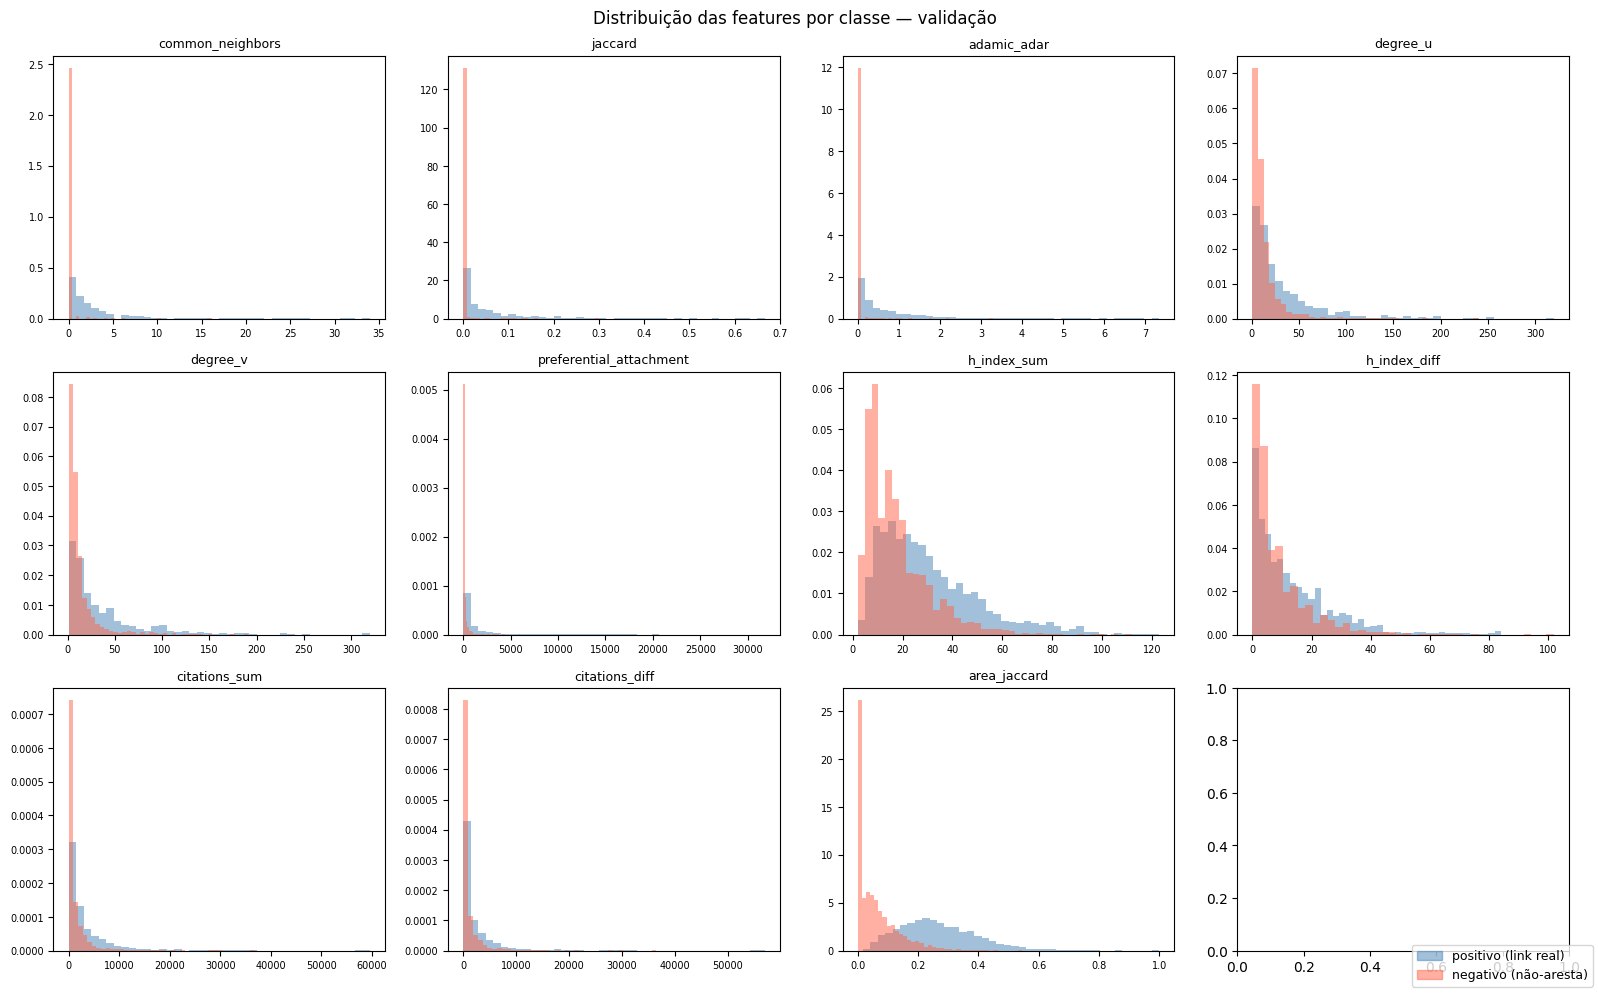

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, FEATURE_COLS):
    for label, color, name in [(1, "steelblue", "positivo"), (0, "tomato", "negativo")]:
        vals = val_features.loc[val_features["label"] == label, col]
        ax.hist(vals, bins=40, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)

handles = [
    plt.Rectangle((0,0),1,1, color="steelblue", alpha=0.5),
    plt.Rectangle((0,0),1,1, color="tomato",    alpha=0.5),
]
fig.legend(handles, ["positivo (link real)", "negativo (não-aresta)"],
           loc="lower right", fontsize=9)
fig.suptitle("Distribuição das features por classe — validação", fontsize=12)
plt.tight_layout()
plt.show()

Avaliando o número total de áreas de pesquisa diferentes entre os autores

In [3]:
import pandas as pd

df = pd.read_csv(AUTHORS_CSV)

all_areas = (
    df["areas"]
    .fillna("")
    .str.split(";")
    .explode()
    .str.strip()
    .loc[lambda s: s != ""]
)

print(f"Áreas únicas : {all_areas.nunique()}")
print(f"Total de entradas (com repetição): {len(all_areas)}")
print("\nTop 20 mais frequentes:")
print(all_areas.value_counts().head(20))

Áreas únicas : 329
Total de entradas (com repetição): 161430

Top 20 mais frequentes:
Medicine (all)                                        6076
Biochemistry                                          2613
Multidisciplinary                                     2276
Biochemistry, Genetics and Molecular Biology (all)    2251
Molecular Biology                                     2178
Chemistry (all)                                       2134
Computer Science Applications                         2031
Agricultural and Biological Sciences (all)            1822
Food Science                                          1731
Organic Chemistry                                     1690
Engineering (all)                                     1686
Biotechnology                                         1672
Chemical Engineering (all)                            1657
Materials Science (all)                               1639
Cell Biology                                          1602
Electrical and Electronic Eng